In [1]:
!pip install --upgrade dill

Defaulting to user installation because normal site-packages is not writeable
  Using cached dill-0.4.0-py3-none-any.whl.metadata (10 kB)
Using cached dill-0.4.0-py3-none-any.whl (119 kB)
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 2.16.1 requires dill<0.3.8,>=0.3.0, but you have dill 0.4.0 which is incompatible.

[notice] A new release of pip is available: 24.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [ ]:
!pip install dill==0.3.8
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0

Defaulting to user installation because normal site-packages is not writeable
  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)
Using cached dill-0.3.8-py3-none-any.whl (116 kB)
  Attempting uninstall: dill
    Found existing installation: dill 0.4.0
    Uninstalling dill-0.4.0:
      Successfully uninstalled dill-0.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 2.16.1 requires dill<0.3.8,>=0.3.0, but you have dill 0.3.8 which is incompatible.

[notice] A new release of pip is available: 24.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable


English samples found: 115320
Telugu samples found:  122173


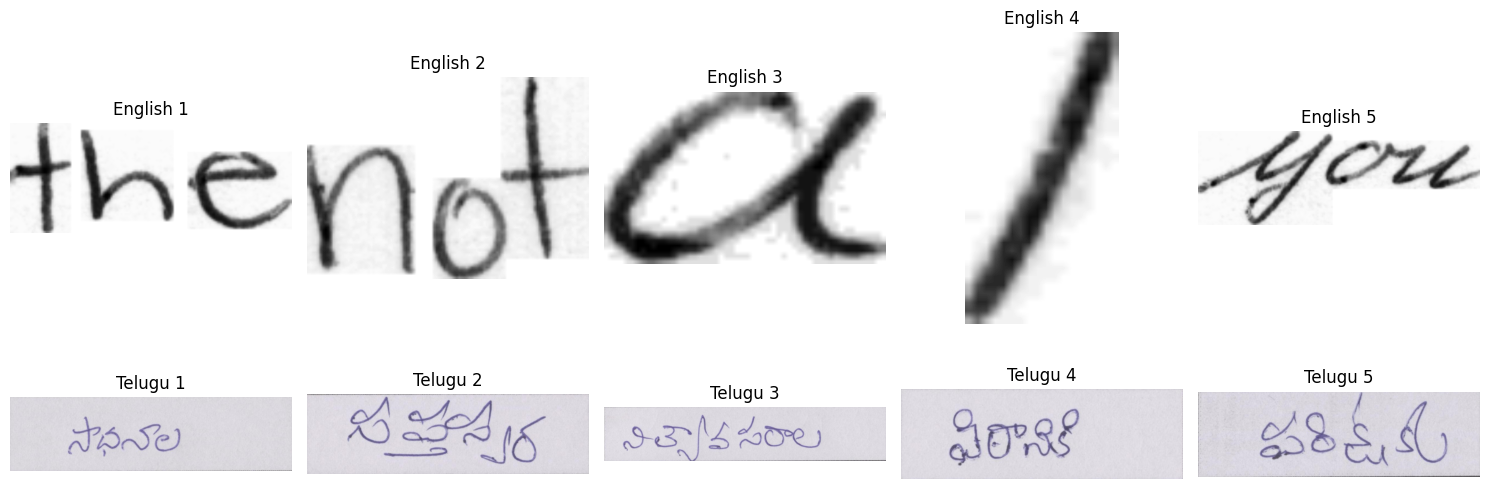

In [1]:
# Step 1: Verify Dataset Accessibility and Show Sample Images
import os, glob, cv2, matplotlib.pyplot as plt

# Paths on HyperGator
english_root = "/blue/eee6778/mulakav/datasets/iam_words"
telugu_root  = "/blue/eee6778/mulakav/datasets/TeluguSeg"

# Collect image paths recursively
english_images = glob.glob(os.path.join(english_root, "**", "*.png"), recursive=True)
telugu_images  = glob.glob(os.path.join(telugu_root, "**", "*.jpg"), recursive=True)

print(f"English samples found: {len(english_images)}")
print(f"Telugu samples found:  {len(telugu_images)}")

import cv2, matplotlib.pyplot as plt
import numpy as np, random

# Randomly select 5 images from each dataset
english_samples = random.sample(english_images, 5)
telugu_samples  = random.sample(telugu_images, 5)

plt.figure(figsize=(15, 6))

# Display 5 English handwriting samples
for i, img_path in enumerate(english_samples):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        h, w = img.shape
        aspect_ratio = w / h
        img_resized = cv2.resize(img, (int(256 * aspect_ratio), 256))
        plt.subplot(2, 5, i + 1)
        plt.imshow(img_resized, cmap="gray")
        plt.title(f"English {i+1}")
        plt.axis("off")

# Display 5 Telugu handwriting samples
for j, img_path in enumerate(telugu_samples):
    img = cv2.imread(img_path)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(2, 5, 5 + j + 1)
        plt.imshow(img_rgb)
        plt.title(f"Telugu {j+1}")
        plt.axis("off")

plt.tight_layout()
plt.show()



In [2]:
#Checking whether dataset is balanced or imbalanced
eng_count = len(english_images)
tel_count = len(telugu_images)

ratio = eng_count / tel_count
print(f"English: {eng_count}, Telugu: {tel_count}, Ratio: {ratio:.2f}")
if 0.8 <= ratio <= 1.2:
    print("Datasets are balanced enough for unpaired training.")
else:
    print("Consider balancing datasets (undersampling/oversampling).")


English: 115320, Telugu: 122173, Ratio: 0.94
Datasets are balanced enough for unpaired training.


In [3]:
# Step 2: Custom PyTorch Dataset & DataLoaders
import os, cv2, random, torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

#  Custom Dataset Class
class HandwritingDataset(Dataset):
    def __init__(self, english_paths, telugu_paths, image_size=128, augment=True):
        self.english_paths = english_paths
        self.telugu_paths = telugu_paths
        self.image_size = image_size
        self.augment = augment

        # Normalization transform → range [-1, 1]
        self.to_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        # Limit to smaller dataset for balance
        return min(len(self.english_paths), len(self.telugu_paths))
    def __getitem__(self, idx):
        while True:  # keep retrying until a valid image pair is found
            eng_path = random.choice(self.english_paths)
            tel_path = random.choice(self.telugu_paths)

            img_en = cv2.imread(eng_path, cv2.IMREAD_GRAYSCALE)
            img_te = cv2.imread(tel_path, cv2.IMREAD_GRAYSCALE)

            # Skip if either image failed to load
            if img_en is None or img_te is None:
                continue

            img_en = cv2.resize(img_en, (self.image_size, self.image_size))
            img_te = cv2.resize(img_te, (self.image_size, self.image_size))

            if self.augment:
                img_en = self.apply_augmentation(img_en)
                img_te = self.apply_augmentation(img_te)

            img_en = np.expand_dims(img_en, axis=2)
            img_te = np.expand_dims(img_te, axis=2)

            img_en = self.to_tensor(img_en)
            img_te = self.to_tensor(img_te)

            return {"english": img_en, "telugu": img_te}


    # Style Augmentation (Cursive/Bold/Calligraphy)
    def apply_augmentation(self, img):
        aug_type = random.choice(["none", "blur", "dilate", "erode", "rotate", "invert"])
        if aug_type == "blur":      # → Cursive
            img = cv2.GaussianBlur(img, (3, 3), 0)
        elif aug_type == "dilate":  # → Bold
            kernel = np.ones((2, 2), np.uint8)
            img = cv2.dilate(img, kernel, iterations=1)
        elif aug_type == "erode":   # → Calligraphy
            kernel = np.ones((2, 2), np.uint8)
            img = cv2.erode(img, kernel, iterations=1)
        elif aug_type == "rotate":
            angle = random.uniform(-8,8)
            M = cv2.getRotationMatrix2D((img.shape[1]/2,img.shape[0]/2), angle, 1)
            img = cv2.warpAffine(img, M, (img.shape[1],img.shape[0]))
        elif aug_type == "invert":
            img = 255 - img
                                  
        return img



#  DataLoader Setup
train_dataset = HandwritingDataset(english_images, telugu_images, image_size=128, augment=True)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4)

# Verify batch loading
batch = next(iter(train_loader))
print(f"English batch shape: {batch['english'].shape}")
print(f"Telugu batch shape:  {batch['telugu'].shape}")


English batch shape: torch.Size([8, 1, 128, 128])
Telugu batch shape:  torch.Size([8, 1, 128, 128])


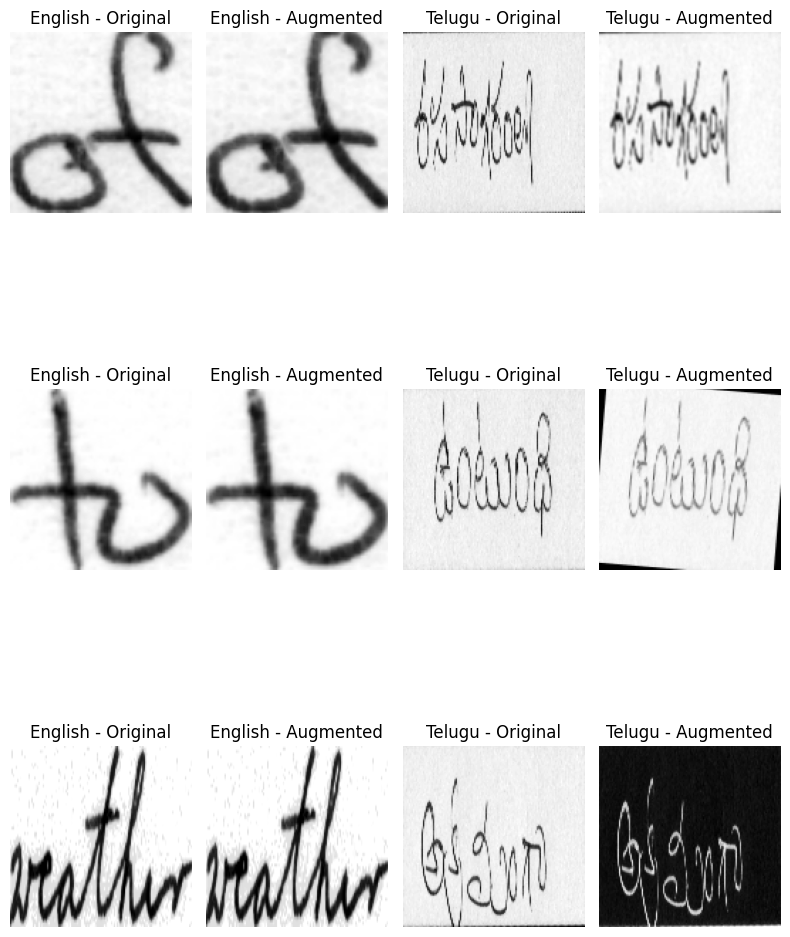

In [4]:
#Optional - Just to see style Augmentation on  original images 
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random

def show_original_vs_augmented(dataset, n=3):
    plt.figure(figsize=(8, 4*n))
    for i in range(n):
        # Randomly select image paths
        eng_path = random.choice(dataset.english_paths)
        tel_path = random.choice(dataset.telugu_paths)

        # --- English ---
        img_en_orig = cv2.imread(eng_path, cv2.IMREAD_GRAYSCALE)
        img_en_resized = cv2.resize(img_en_orig, (dataset.image_size, dataset.image_size))
        img_en_aug = dataset.apply_augmentation(img_en_resized.copy())

        # --- Telugu ---
        img_te_orig = cv2.imread(tel_path, cv2.IMREAD_GRAYSCALE)
        img_te_resized = cv2.resize(img_te_orig, (dataset.image_size, dataset.image_size))
        img_te_aug = dataset.apply_augmentation(img_te_resized.copy())

        # Plot English Original vs Augmented
        plt.subplot(n, 4, 4*i + 1)
        plt.imshow(img_en_resized, cmap='gray')
        plt.title("English - Original")
        plt.axis('off')

        plt.subplot(n, 4, 4*i + 2)
        plt.imshow(img_en_aug, cmap='gray')
        plt.title("English - Augmented")
        plt.axis('off')

        # Plot Telugu Original vs Augmented
        plt.subplot(n, 4, 4*i + 3)
        plt.imshow(img_te_resized, cmap='gray')
        plt.title("Telugu - Original")
        plt.axis('off')

        plt.subplot(n, 4, 4*i + 4)
        plt.imshow(img_te_aug, cmap='gray')
        plt.title("Telugu - Augmented")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Display 3 random samples (Original vs Augmented)
show_original_vs_augmented(train_dataset, n=3) # cursive (blurred), Calligraphic (Eroded), Bold (Dilated)

In [5]:
# Step 3 — Define CycleGAN Architecture
import torch
import torch.nn as nn
import itertools

# 3.1 Helper blocks for Generator & Discriminator
class ConvBlock(nn.Module):
    """Downsampling block: Conv → InstanceNorm → LeakyReLU"""
    def __init__(self, in_c, out_c, normalize=True):
        super().__init__()
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x): return self.block(x)


class DeconvBlock(nn.Module):
    """Upsampling block: ConvTranspose → InstanceNorm → ReLU"""
    def __init__(self, in_c, out_c, dropout=False):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(out_c),
            nn.ReLU(inplace=True)
        ]
        if dropout:
            layers.append(nn.Dropout(0.5))
        self.block = nn.Sequential(*layers)

    def forward(self, x): return self.block(x)

# 3.2 Generator (U-Net style)
class Generator(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        # Encoder (downsampling)
        self.down1 = ConvBlock(in_channels, 64, normalize=False)
        self.down2 = ConvBlock(64, 128)
        self.down3 = ConvBlock(128, 256)
        self.down4 = ConvBlock(256, 512)

        # Decoder (upsampling)
        self.up1 = DeconvBlock(512, 256, dropout=True)
        self.up2 = DeconvBlock(256, 128)
        self.up3 = DeconvBlock(128, 64)
        self.final = nn.Sequential(
            nn.ConvTranspose2d(64, out_channels, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        bottleneck = self.down4(d3)
        u1 = self.up1(bottleneck)
        u2 = self.up2(u1)
        u3 = self.up3(u2)
        out = self.final(u3)
        return out

# 3.3 Discriminator (PatchGAN)
class Discriminator(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.model = nn.Sequential(
            ConvBlock(in_channels, 64, normalize=False),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
            nn.Conv2d(256, 1, 4, 1, 1)
        )

    def forward(self, x): return self.model(x)

# 3.4 Instantiate Networks
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G_EN2TE = Generator().to(device)   # English → Telugu
G_TE2EN = Generator().to(device)   # Telugu → English
D_EN = Discriminator().to(device)  # Discriminator for English
D_TE = Discriminator().to(device)  # Discriminator for Telugu

# 3.5 Define Optimizers and Losses
criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()

optimizer_G = torch.optim.Adam(
    itertools.chain(G_EN2TE.parameters(), G_TE2EN.parameters()),
    lr=0.0004, betas=(0.5, 0.999)
)
optimizer_D = torch.optim.Adam(
    itertools.chain(D_EN.parameters(), D_TE.parameters()),
    lr=0.0004, betas=(0.5, 0.999)
)

print("CycleGAN architecture initialized successfully.")
print("G_EN2TE:", sum(p.numel() for p in G_EN2TE.parameters())/1e6, "M")
print("G_TE2EN:", sum(p.numel() for p in G_TE2EN.parameters())/1e6, "M")
print("D_EN:", sum(p.numel() for p in D_EN.parameters())/1e6, "M")
print("D_TE:", sum(p.numel() for p in D_TE.parameters())/1e6, "M")



CycleGAN architecture initialized successfully.
G_EN2TE: 5.508033 M
G_TE2EN: 5.508033 M
D_EN: 0.660929 M
D_TE: 0.660929 M


In [ ]:

# Step 4 — CycleGAN Training Loop

import torch
import itertools
from datetime import datetime

# Training Configuration
num_epochs = 100                # Full training
lambda_cycle = 10.0             # Cycle-consistency loss weight
lambda_identity = 5.0           # Identity preservation weight
save_interval = 10              # Save checkpoints every N epochs

# Logging buffers
losses_G, losses_D = [], []

# Confirm device
print(f" Using device: {device}")
start_time = datetime.now()

# Training Loop
for epoch in range(num_epochs):
    print(f"\n Epoch [{epoch+1}/{num_epochs}] -----------------------", flush=True)

    for i, batch in enumerate(train_loader):
        real_EN = batch["english"].to(device)
        real_TE = batch["telugu"].to(device)

        # ====== Train Generators ======
        optimizer_G.zero_grad()

        fake_TE = G_EN2TE(real_EN)         # English → Telugu
        rec_EN  = G_TE2EN(fake_TE)         # Reconstruct English
        fake_EN = G_TE2EN(real_TE)         # Telugu → English
        rec_TE  = G_EN2TE(fake_EN)         # Reconstruct Telugu

        # Identity preservation
        idt_EN = G_TE2EN(real_EN)
        idt_TE = G_EN2TE(real_TE)

        # GAN loss
        loss_GAN_EN2TE = criterion_GAN(D_TE(fake_TE), torch.ones_like(D_TE(fake_TE)))
        loss_GAN_TE2EN = criterion_GAN(D_EN(fake_EN), torch.ones_like(D_EN(fake_EN)))

        # Cycle & identity losses
        loss_cycle_EN = criterion_cycle(rec_EN, real_EN)
        loss_cycle_TE = criterion_cycle(rec_TE, real_TE)
        loss_idt_EN = criterion_identity(idt_EN, real_EN)
        loss_idt_TE = criterion_identity(idt_TE, real_TE)

        # Total generator loss
        loss_G = (loss_GAN_EN2TE + loss_GAN_TE2EN) + \
                 lambda_cycle * (loss_cycle_EN + loss_cycle_TE) + \
                 lambda_identity * (loss_idt_EN + loss_idt_TE)

        loss_G.backward()
        optimizer_G.step()

        # ====== Train Discriminators ======
        optimizer_D.zero_grad()

        # English discriminator
        loss_D_EN_real = criterion_GAN(D_EN(real_EN), torch.ones_like(D_EN(real_EN)))
        loss_D_EN_fake = criterion_GAN(D_EN(fake_EN.detach()), torch.zeros_like(D_EN(fake_EN)))
        loss_D_EN = 0.5 * (loss_D_EN_real + loss_D_EN_fake)

        # Telugu discriminator
        loss_D_TE_real = criterion_GAN(D_TE(real_TE), torch.ones_like(D_TE(real_TE)))
        loss_D_TE_fake = criterion_GAN(D_TE(fake_TE.detach()), torch.zeros_like(D_TE(fake_TE)))
        loss_D_TE = 0.5 * (loss_D_TE_real + loss_D_TE_fake)

        # Total discriminator loss
        loss_D = loss_D_EN + loss_D_TE
        loss_D.backward()
        optimizer_D.step()

        # Log every 50 batches
        if i % 50 == 0:
            print(f"Epoch {epoch+1} | Batch {i:05d} | "
                  f"G_loss={loss_G.item():.4f} | D_loss={loss_D.item():.4f}", flush=True)

    # End-of-epoch summary
    losses_G.append(loss_G.item())
    losses_D.append(loss_D.item())
    print(f" Epoch [{epoch+1}] complete — "
          f"G_loss={loss_G.item():.4f}, D_loss={loss_D.item():.4f}", flush=True)

    # Save checkpoints every few epochs
    if (epoch + 1) % save_interval == 0:
        os.makedirs("checkpoints", exist_ok=True)
        torch.save(G_EN2TE.state_dict(), f"checkpoints/G_EN2TE_epoch{epoch+1}.pth")
        torch.save(G_TE2EN.state_dict(), f"checkpoints/G_TE2EN_epoch{epoch+1}.pth")
        torch.save(D_EN.state_dict(), f"checkpoints/D_EN_epoch{epoch+1}.pth")
        torch.save(D_TE.state_dict(), f"checkpoints/D_TE_epoch{epoch+1}.pth")
        print(f" Saved checkpoints at epoch {epoch+1}", flush=True)


# Training Complete
end_time = datetime.now()
print("\n Training complete!")
print(f" Total training time: {end_time - start_time}")


 Using device: cuda

 Epoch [1/100] -----------------------
Epoch 1 | Batch 00000 | G_loss=28.9504 | D_loss=1.3781
Epoch 1 | Batch 00050 | G_loss=8.4954 | D_loss=0.0387
Epoch 1 | Batch 00100 | G_loss=7.9192 | D_loss=0.0254
Epoch 1 | Batch 00150 | G_loss=6.9945 | D_loss=0.0276
Epoch 1 | Batch 00200 | G_loss=6.3306 | D_loss=0.0383
Epoch 1 | Batch 00250 | G_loss=6.6578 | D_loss=0.1698
Epoch 1 | Batch 00300 | G_loss=4.9154 | D_loss=0.1887
Epoch 1 | Batch 00350 | G_loss=4.8134 | D_loss=0.1662
Epoch 1 | Batch 00400 | G_loss=4.5174 | D_loss=0.1731
Epoch 1 | Batch 00450 | G_loss=5.0958 | D_loss=0.1723
Epoch 1 | Batch 00500 | G_loss=4.5084 | D_loss=0.1438
Epoch 1 | Batch 00550 | G_loss=3.4972 | D_loss=0.2024
Epoch 1 | Batch 00600 | G_loss=3.9470 | D_loss=0.0947
Epoch 1 | Batch 00650 | G_loss=4.2043 | D_loss=0.1144
Epoch 1 | Batch 00700 | G_loss=5.1997 | D_loss=0.2723
Epoch 1 | Batch 00750 | G_loss=3.7179 | D_loss=0.1689
Epoch 1 | Batch 00800 | G_loss=3.9838 | D_loss=0.1564
Epoch 1 | Batch 00850

Premature end of JPEG file


Epoch 1 | Batch 02550 | G_loss=3.5847 | D_loss=0.0688
Epoch 1 | Batch 02600 | G_loss=4.2827 | D_loss=0.1264
Epoch 1 | Batch 02650 | G_loss=3.1691 | D_loss=0.1308
Epoch 1 | Batch 02700 | G_loss=3.5478 | D_loss=0.0941
Epoch 1 | Batch 02750 | G_loss=3.1192 | D_loss=0.1247
Epoch 1 | Batch 02800 | G_loss=3.4960 | D_loss=0.0967
Epoch 1 | Batch 02850 | G_loss=3.8840 | D_loss=0.1595
Epoch 1 | Batch 02900 | G_loss=4.0748 | D_loss=0.1374
Epoch 1 | Batch 02950 | G_loss=3.7747 | D_loss=0.1410
Epoch 1 | Batch 03000 | G_loss=3.7457 | D_loss=0.0582
Epoch 1 | Batch 03050 | G_loss=3.9773 | D_loss=0.1568
Epoch 1 | Batch 03100 | G_loss=3.8104 | D_loss=0.1261
Epoch 1 | Batch 03150 | G_loss=3.3018 | D_loss=0.1040
Epoch 1 | Batch 03200 | G_loss=3.5891 | D_loss=0.0968
Epoch 1 | Batch 03250 | G_loss=3.6025 | D_loss=0.0595
Epoch 1 | Batch 03300 | G_loss=3.1956 | D_loss=0.1284
Epoch 1 | Batch 03350 | G_loss=3.5641 | D_loss=0.1212
Epoch 1 | Batch 03400 | G_loss=3.3519 | D_loss=0.0889
Epoch 1 | Batch 03450 | G_lo

Premature end of JPEG file


Epoch 1 | Batch 08300 | G_loss=3.1269 | D_loss=0.0980
Epoch 1 | Batch 08350 | G_loss=3.6202 | D_loss=0.3003
Epoch 1 | Batch 08400 | G_loss=3.4894 | D_loss=0.2161
Epoch 1 | Batch 08450 | G_loss=3.1856 | D_loss=0.2347
Epoch 1 | Batch 08500 | G_loss=3.3227 | D_loss=0.1986
Epoch 1 | Batch 08550 | G_loss=2.7937 | D_loss=0.1805
Epoch 1 | Batch 08600 | G_loss=3.2624 | D_loss=0.1403
Epoch 1 | Batch 08650 | G_loss=3.3787 | D_loss=0.1418
Epoch 1 | Batch 08700 | G_loss=3.8764 | D_loss=0.1582
Epoch 1 | Batch 08750 | G_loss=3.0583 | D_loss=0.1608
Epoch 1 | Batch 08800 | G_loss=3.3439 | D_loss=0.1363
Epoch 1 | Batch 08850 | G_loss=3.1840 | D_loss=0.1697
Epoch 1 | Batch 08900 | G_loss=3.1416 | D_loss=0.1231
Epoch 1 | Batch 08950 | G_loss=2.7037 | D_loss=0.1332
Epoch 1 | Batch 09000 | G_loss=3.2621 | D_loss=0.1204
Epoch 1 | Batch 09050 | G_loss=2.6592 | D_loss=0.1745
Epoch 1 | Batch 09100 | G_loss=3.6945 | D_loss=0.1079
Epoch 1 | Batch 09150 | G_loss=3.6417 | D_loss=0.1653
Epoch 1 | Batch 09200 | G_lo

...

Epoch 76 | Batch 13750 | G_loss=3.0367 | D_loss=0.0479
Epoch 76 | Batch 13800 | G_loss=2.8982 | D_loss=0.0953


Premature end of JPEG file


Epoch 76 | Batch 13850 | G_loss=3.3410 | D_loss=0.0961
Epoch 76 | Batch 13900 | G_loss=2.7109 | D_loss=0.1040
Epoch 76 | Batch 13950 | G_loss=3.5112 | D_loss=0.1417
Epoch 76 | Batch 14000 | G_loss=3.2410 | D_loss=0.0712
Epoch 76 | Batch 14050 | G_loss=3.2983 | D_loss=0.0753
Epoch 76 | Batch 14100 | G_loss=3.3158 | D_loss=0.1248
Epoch 76 | Batch 14150 | G_loss=2.9839 | D_loss=0.0410
Epoch 76 | Batch 14200 | G_loss=3.0433 | D_loss=0.0496
Epoch 76 | Batch 14250 | G_loss=2.4633 | D_loss=0.1886
Epoch 76 | Batch 14300 | G_loss=2.6798 | D_loss=0.0706
Epoch 76 | Batch 14350 | G_loss=2.8991 | D_loss=0.0562
Epoch 76 | Batch 14400 | G_loss=2.5464 | D_loss=0.1131
 Epoch [76] complete — G_loss=2.8994, D_loss=0.1067

 Epoch [77/100] -----------------------
Epoch 77 | Batch 00000 | G_loss=3.3013 | D_loss=0.0850
Epoch 77 | Batch 00050 | G_loss=2.7021 | D_loss=0.0663
Epoch 77 | Batch 00100 | G_loss=2.8435 | D_loss=0.1231
Epoch 77 | Batch 00150 | G_loss=3.1400 | D_loss=0.0411
Epoch 77 | Batch 00200 | G_

Premature end of JPEG file


Epoch 77 | Batch 00300 | G_loss=3.0928 | D_loss=0.0653
Epoch 77 | Batch 00350 | G_loss=3.4506 | D_loss=0.0442
Epoch 77 | Batch 00400 | G_loss=3.0071 | D_loss=0.0697
Epoch 77 | Batch 00450 | G_loss=3.0372 | D_loss=0.0781
Epoch 77 | Batch 00500 | G_loss=2.5481 | D_loss=0.1486
Epoch 77 | Batch 00550 | G_loss=3.3744 | D_loss=0.0514
Epoch 77 | Batch 00600 | G_loss=2.8613 | D_loss=0.0818
Epoch 77 | Batch 00650 | G_loss=2.9108 | D_loss=0.0500
Epoch 77 | Batch 00700 | G_loss=2.3915 | D_loss=0.1070
Epoch 77 | Batch 00750 | G_loss=3.1170 | D_loss=0.0546
Epoch 77 | Batch 00800 | G_loss=3.3148 | D_loss=0.0644
Epoch 77 | Batch 00850 | G_loss=2.6180 | D_loss=0.0770
Epoch 77 | Batch 00900 | G_loss=2.8004 | D_loss=0.0840
Epoch 77 | Batch 00950 | G_loss=3.2362 | D_loss=0.0966
Epoch 77 | Batch 01000 | G_loss=2.9054 | D_loss=0.0513
Epoch 77 | Batch 01050 | G_loss=3.0683 | D_loss=0.0807
Epoch 77 | Batch 01100 | G_loss=2.5838 | D_loss=0.0865
Epoch 77 | Batch 01150 | G_loss=3.2133 | D_loss=0.0672
Epoch 77 |

In [21]:
import torch, os
from datetime import datetime

# ==== Configuration ====
epoch_start = 80           # last full training checkpoint
extra_epochs = 5           # fine-tune for 5 more epochs
lambda_cycle = 25.0        # ↑ preserve structure
lambda_identity = 15.0     # ↑ emphasize style retention
save_interval = 1          # save every epoch

# ==== Paths ====
ckpt_dir = "/blue/eee6778/mulakav/checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

# ==== Load Previous Checkpoints ====
print(f"\nLoading checkpoints from epoch {epoch_start}...\n")

G_EN2TE.load_state_dict(torch.load(os.path.join(ckpt_dir, f"G_EN2TE_epoch{epoch_start}.pth"), map_location=device))
G_TE2EN.load_state_dict(torch.load(os.path.join(ckpt_dir, f"G_TE2EN_epoch{epoch_start}.pth"), map_location=device))
D_EN.load_state_dict(torch.load(os.path.join(ckpt_dir, f"D_EN_epoch{epoch_start}.pth"), map_location=device))
D_TE.load_state_dict(torch.load(os.path.join(ckpt_dir, f"D_TE_epoch{epoch_start}.pth"), map_location=device))

G_EN2TE.train()
G_TE2EN.train()
D_EN.train()
D_TE.train()

print(f"✅ Loaded all models. Starting fine-tuning from epoch {epoch_start+1}...\n")

# ==== Fine-tune Loop ====
for epoch in range(epoch_start, epoch_start + extra_epochs):
    print(f"\nEpoch [{epoch+1}/{epoch_start + extra_epochs}] -----------------------", flush=True)
    G_epoch_loss, D_epoch_loss = 0.0, 0.0

    for i, batch in enumerate(train_loader):
        real_EN = batch["english"].to(device)
        real_TE = batch["telugu"].to(device)

        # ====== Train Generators ======
        optimizer_G.zero_grad()

        fake_TE = G_EN2TE(real_EN)
        rec_EN  = G_TE2EN(fake_TE)
        fake_EN = G_TE2EN(real_TE)
        rec_TE  = G_EN2TE(fake_EN)

        # Identity preservation
        idt_EN = G_TE2EN(real_EN)
        idt_TE = G_EN2TE(real_TE)

        # Losses
        loss_GAN_EN2TE = criterion_GAN(D_TE(fake_TE), torch.ones_like(D_TE(fake_TE)))
        loss_GAN_TE2EN = criterion_GAN(D_EN(fake_EN), torch.ones_like(D_EN(fake_EN)))
        loss_cycle_EN  = criterion_cycle(rec_EN, real_EN)
        loss_cycle_TE  = criterion_cycle(rec_TE, real_TE)
        loss_idt_EN    = criterion_identity(idt_EN, real_EN)
        loss_idt_TE    = criterion_identity(idt_TE, real_TE)

        # Total generator loss
        loss_G = (loss_GAN_EN2TE + loss_GAN_TE2EN) + \
                 lambda_cycle * (loss_cycle_EN + loss_cycle_TE) + \
                 lambda_identity * (loss_idt_EN + loss_idt_TE)

        loss_G.backward()
        optimizer_G.step()

        # ====== Train Discriminators ======
        optimizer_D.zero_grad()

        loss_D_EN_real = criterion_GAN(D_EN(real_EN), torch.ones_like(D_EN(real_EN)))
        loss_D_EN_fake = criterion_GAN(D_EN(fake_EN.detach()), torch.zeros_like(D_EN(fake_EN)))
        loss_D_EN = 0.5 * (loss_D_EN_real + loss_D_EN_fake)

        loss_D_TE_real = criterion_GAN(D_TE(real_TE), torch.ones_like(D_TE(real_TE)))
        loss_D_TE_fake = criterion_GAN(D_TE(fake_TE.detach()), torch.zeros_like(D_TE(fake_TE)))
        loss_D_TE = 0.5 * (loss_D_TE_real + loss_D_TE_fake)

        loss_D = loss_D_EN + loss_D_TE
        loss_D.backward()
        optimizer_D.step()

        G_epoch_loss += loss_G.item()
        D_epoch_loss += loss_D.item()

        if i % 50 == 0:
            print(f"Batch {i:05d} | G_loss={loss_G.item():.4f} | D_loss={loss_D.item():.4f}", flush=True)

    # ==== End of Epoch ====
    print(f"Epoch [{epoch+1}] complete — Avg G_loss={G_epoch_loss/len(train_loader):.4f}, D_loss={D_epoch_loss/len(train_loader):.4f}", flush=True)

    # Save fine-tuned checkpoints
    torch.save(G_EN2TE.state_dict(), os.path.join(ckpt_dir, f"G_EN2TE_finetune{epoch+1}.pth"))
    torch.save(G_TE2EN.state_dict(), os.path.join(ckpt_dir, f"G_TE2EN_finetune{epoch+1}.pth"))
    print(f"✅ Saved fine-tune checkpoints for epoch {epoch+1}")

print("\n🎯 Fine-tuning complete! All checkpoints saved inside:")
print(f"   {ckpt_dir}")



Loading checkpoints from epoch 80...

✅ Loaded all models. Starting fine-tuning from epoch 81...


Epoch [81/85] -----------------------
Batch 00000 | G_loss=4.9478 | D_loss=0.0570
Batch 00050 | G_loss=4.8978 | D_loss=0.0580
Batch 00100 | G_loss=5.4209 | D_loss=0.0786
Batch 00150 | G_loss=4.9995 | D_loss=0.0579
Batch 00200 | G_loss=5.3618 | D_loss=0.0643
Batch 00250 | G_loss=5.6095 | D_loss=0.0644
Batch 00300 | G_loss=4.9049 | D_loss=0.0564
Batch 00350 | G_loss=4.8073 | D_loss=0.0618
Batch 00400 | G_loss=5.0910 | D_loss=0.0440
Batch 00450 | G_loss=5.1639 | D_loss=0.0562
Batch 00500 | G_loss=4.4375 | D_loss=0.0408
Batch 00550 | G_loss=5.2541 | D_loss=0.0709
Batch 00600 | G_loss=4.8522 | D_loss=0.0503
Batch 00650 | G_loss=4.9101 | D_loss=0.0748
Batch 00700 | G_loss=5.0879 | D_loss=0.0431
Batch 00750 | G_loss=4.7425 | D_loss=0.0489
Batch 00800 | G_loss=4.7120 | D_loss=0.0388
Batch 00850 | G_loss=5.0525 | D_loss=0.0358
Batch 00900 | G_loss=4.7435 | D_loss=0.0572
Batch 00950 | G_loss=4.797

Premature end of JPEG file


Batch 01450 | G_loss=5.3295 | D_loss=0.0468
Batch 01500 | G_loss=5.3274 | D_loss=0.0312
Batch 01550 | G_loss=5.1480 | D_loss=0.0344
Batch 01600 | G_loss=5.1165 | D_loss=0.0434
Batch 01650 | G_loss=4.8378 | D_loss=0.0403
Batch 01700 | G_loss=5.6361 | D_loss=0.0341
Batch 01750 | G_loss=4.7723 | D_loss=0.0357
Batch 01800 | G_loss=5.2409 | D_loss=0.0473
Batch 01850 | G_loss=4.3477 | D_loss=0.0764
Batch 01900 | G_loss=5.2093 | D_loss=0.0639
Batch 01950 | G_loss=4.9988 | D_loss=0.0606
Batch 02000 | G_loss=4.9163 | D_loss=0.0402
Batch 02050 | G_loss=4.6134 | D_loss=0.0256
Batch 02100 | G_loss=5.0648 | D_loss=0.0410
Batch 02150 | G_loss=4.8590 | D_loss=0.0558
Batch 02200 | G_loss=4.6030 | D_loss=0.0393
Batch 02250 | G_loss=4.7418 | D_loss=0.0426
Batch 02300 | G_loss=6.6093 | D_loss=0.0731
Batch 02350 | G_loss=4.8596 | D_loss=0.0475
Batch 02400 | G_loss=4.7538 | D_loss=0.0442
Batch 02450 | G_loss=5.0706 | D_loss=0.0439
Batch 02500 | G_loss=4.7205 | D_loss=0.0456
Batch 02550 | G_loss=5.3640 | D_

Premature end of JPEG file


Batch 04150 | G_loss=4.7731 | D_loss=0.0325
Batch 04200 | G_loss=5.1449 | D_loss=0.0294
Batch 04250 | G_loss=4.8562 | D_loss=0.0313
Batch 04300 | G_loss=4.9340 | D_loss=0.0722
Batch 04350 | G_loss=5.5184 | D_loss=0.0565
Batch 04400 | G_loss=4.5060 | D_loss=0.0370
Batch 04450 | G_loss=4.7429 | D_loss=0.0267
Batch 04500 | G_loss=4.6013 | D_loss=0.0391
Batch 04550 | G_loss=4.9539 | D_loss=0.0323
Batch 04600 | G_loss=5.1620 | D_loss=0.0386
Batch 04650 | G_loss=5.2003 | D_loss=0.0374
Batch 04700 | G_loss=4.9916 | D_loss=0.0326
Batch 04750 | G_loss=5.2526 | D_loss=0.0458
Batch 04800 | G_loss=4.8116 | D_loss=0.0444
Batch 04850 | G_loss=4.6576 | D_loss=0.0282
Batch 04900 | G_loss=4.8957 | D_loss=0.0362
Batch 04950 | G_loss=4.9407 | D_loss=0.0395
Batch 05000 | G_loss=5.0182 | D_loss=0.0393
Batch 05050 | G_loss=5.1180 | D_loss=0.0300
Batch 05100 | G_loss=5.1447 | D_loss=0.0561
Batch 05150 | G_loss=5.0931 | D_loss=0.0585
Batch 05200 | G_loss=4.6660 | D_loss=0.0318
Batch 05250 | G_loss=4.8931 | D_

Premature end of JPEG file


Batch 03850 | G_loss=5.3828 | D_loss=0.0374
Batch 03900 | G_loss=4.9489 | D_loss=0.0246
Batch 03950 | G_loss=5.6505 | D_loss=0.0182
Batch 04000 | G_loss=5.4775 | D_loss=0.0211
Batch 04050 | G_loss=4.5844 | D_loss=0.0296
Batch 04100 | G_loss=5.3465 | D_loss=0.0161
Batch 04150 | G_loss=5.1341 | D_loss=0.0150
Batch 04200 | G_loss=5.0551 | D_loss=0.0203
Batch 04250 | G_loss=4.9505 | D_loss=0.0249
Batch 04300 | G_loss=5.2787 | D_loss=0.0174
Batch 04350 | G_loss=5.0054 | D_loss=0.0325
Batch 04400 | G_loss=4.6817 | D_loss=0.0311
Batch 04450 | G_loss=4.8412 | D_loss=0.0216
Batch 04500 | G_loss=5.2002 | D_loss=0.0287
Batch 04550 | G_loss=5.3528 | D_loss=0.0228
Batch 04600 | G_loss=4.9071 | D_loss=0.0284
Batch 04650 | G_loss=4.8095 | D_loss=0.0206
Batch 04700 | G_loss=5.1463 | D_loss=0.0292
Batch 04750 | G_loss=5.2732 | D_loss=0.0310
Batch 04800 | G_loss=5.2820 | D_loss=0.0300
Batch 04850 | G_loss=5.1589 | D_loss=0.0313
Batch 04900 | G_loss=4.9250 | D_loss=0.0192
Batch 04950 | G_loss=5.4369 | D_

Premature end of JPEG file


Batch 13300 | G_loss=4.9256 | D_loss=0.0244
Batch 13350 | G_loss=4.5112 | D_loss=0.0156
Batch 13400 | G_loss=5.9664 | D_loss=0.0148
Batch 13450 | G_loss=5.0796 | D_loss=0.0172
Batch 13500 | G_loss=5.3455 | D_loss=0.0141
Batch 13550 | G_loss=4.8776 | D_loss=0.0204
Batch 13600 | G_loss=4.9776 | D_loss=0.0261
Batch 13650 | G_loss=5.6281 | D_loss=0.0192
Batch 13700 | G_loss=5.3900 | D_loss=0.0192
Batch 13750 | G_loss=5.0956 | D_loss=0.0133
Batch 13800 | G_loss=5.1360 | D_loss=0.0142
Batch 13850 | G_loss=4.8722 | D_loss=0.0136
Batch 13900 | G_loss=4.9847 | D_loss=0.0198
Batch 13950 | G_loss=5.2128 | D_loss=0.0177
Batch 14000 | G_loss=5.2880 | D_loss=0.0126
Batch 14050 | G_loss=4.8760 | D_loss=0.0214
Batch 14100 | G_loss=5.1873 | D_loss=0.0201
Batch 14150 | G_loss=4.9795 | D_loss=0.0142
Batch 14200 | G_loss=4.7925 | D_loss=0.0119
Batch 14250 | G_loss=5.2965 | D_loss=0.0379
Batch 14300 | G_loss=5.1452 | D_loss=0.0131
Batch 14350 | G_loss=5.1317 | D_loss=0.0103
Batch 14400 | G_loss=5.2399 | D_

In [31]:
# ==========================================================
#   FINAL WORKING EVALUATION FOR FINETUNE EPOCHS 81–85
#   (USES THE EXACT SAME ARCHITECTURE AS TRAINING + FINETUNING)
# ==========================================================

import os, cv2, csv, random, glob
import numpy as np
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
import torch
import torch.nn as nn

# -------------------------------
# 1. ARCHITECTURE (EXACT ORIGINAL VERSION)
# -------------------------------

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, normalize=True):
        super().__init__()
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class DeconvBlock(nn.Module):
    """Upsampling block used during ALL your training + fine-tuning"""
    def __init__(self, in_c, out_c, dropout=False):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(out_c),
            nn.ReLU(inplace=True)
        ]
        if dropout:
            layers.append(nn.Dropout(0.5))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class Generator(nn.Module):
    """Original U-Net-style generator"""
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        # Encoder
        self.down1 = ConvBlock(in_channels, 64, normalize=False)
        self.down2 = ConvBlock(64, 128)
        self.down3 = ConvBlock(128, 256)
        self.down4 = ConvBlock(256, 512)

        # Decoder (IMPORTANT: Uses DeconvBlock, NOT Sequential)
        self.up1 = DeconvBlock(512, 256, dropout=True)
        self.up2 = DeconvBlock(256, 128)
        self.up3 = DeconvBlock(128, 64)

        # Final layer
        self.final = nn.Sequential(
            nn.ConvTranspose2d(64, out_channels, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        bottleneck = self.down4(d3)
        u1 = self.up1(bottleneck)
        u2 = self.up2(u1)
        u3 = self.up3(u2)
        return self.final(u3)


# -------------------------------
# 2. PATHS
# -------------------------------

base_dir = "/blue/eee6778/mulakav"
orig_en_dir = f"{base_dir}/datasets/iam_words"
orig_te_dir = f"{base_dir}/datasets/TeluguSeg"
ckpt_dir    = f"{base_dir}/checkpoints"

epochs_to_test = [81, 82, 83, 84, 85]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# -------------------------------
# 3. Helper Functions
# -------------------------------

def safe_read(path):
    if path is None or not os.path.exists(path):
        return None
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return cv2.resize(img, (128,128))


def random_image(folder):
    imgs = glob.glob(os.path.join(folder, "**/*.*"), recursive=True)
    imgs = [i for i in imgs if i.lower().endswith((".png",".jpg",".jpeg"))]
    return random.choice(imgs) if imgs else None


# -------------------------------
# 4. Evaluation Loop
# -------------------------------

final_results = []

for epoch in epochs_to_test:
    print(f"\n🔍 Evaluating FINETUNE epoch {epoch}...\n")

    G_EN2TE = Generator().to(device)
    G_TE2EN = Generator().to(device)

    # Load fine-tuned weights (these were saved as finetuneXX.pth)
    G_EN2TE.load_state_dict(torch.load(f"{ckpt_dir}/G_EN2TE_finetune{epoch}.pth", map_location=device))
    G_TE2EN.load_state_dict(torch.load(f"{ckpt_dir}/G_TE2EN_finetune{epoch}.pth", map_location=device))

    G_EN2TE.eval()
    G_TE2EN.eval()

    results = []

    for _ in tqdm(range(20)):  # Evaluate 20 random pairs
        en_orig = safe_read(random_image(orig_en_dir))
        te_orig = safe_read(random_image(orig_te_dir))

        if en_orig is None or te_orig is None:
            continue

        # English → Telugu
        inp_en = torch.tensor(en_orig/127.5 - 1.0).unsqueeze(0).unsqueeze(0).float().to(device)
        with torch.no_grad():
            gen_te = G_EN2TE(inp_en).squeeze().cpu().numpy()

        gen_te = ((gen_te + 1)/2 * 255).astype(np.uint8)

        results.append([
            "EN→TE",
            np.mean((en_orig - gen_te)**2),
            ssim(en_orig, gen_te),
            psnr(en_orig, gen_te)
        ])

        # Telugu → English
        inp_te = torch.tensor(te_orig/127.5 - 1.0).unsqueeze(0).unsqueeze(0).float().to(device)
        with torch.no_grad():
            gen_en = G_TE2EN(inp_te).squeeze().cpu().numpy()

        gen_en = ((gen_en + 1)/2 * 255).astype(np.uint8)

        results.append([
            "TE→EN",
            np.mean((te_orig - gen_en)**2),
            ssim(te_orig, gen_en),
            psnr(te_orig, gen_en)
        ])

    # Average metrics
    en2te = [r for r in results if r[0]=="EN→TE"]
    te2en = [r for r in results if r[0]=="TE→EN"]

    avg_ssim_en = np.mean([r[2] for r in en2te])
    avg_mse_en  = np.mean([r[1] for r in en2te])

    avg_ssim_te = np.mean([r[2] for r in te2en])
    avg_mse_te  = np.mean([r[1] for r in te2en])

    print(f"📌 FINETUNE Epoch {epoch} Summary:")
    print(f" EN→TE: SSIM={avg_ssim_en:.4f}, MSE={avg_mse_en:.1f}")
    print(f" TE→EN: SSIM={avg_ssim_te:.4f}, MSE={avg_mse_te:.1f}")

    final_results.append([
        epoch, avg_ssim_en, avg_mse_en, avg_ssim_te, avg_mse_te
    ])


# -------------------------------
# 5. Save CSV
# -------------------------------

out_dir = f"{base_dir}/epoch_evaluation"
os.makedirs(out_dir, exist_ok=True)

csv_path = f"{out_dir}/finetune_metrics_81_85.csv"

with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Epoch","EN→TE SSIM","EN→TE MSE","TE→EN SSIM","TE→EN MSE"])
    writer.writerows(final_results)

print(f"\n✅ Evaluation Complete! Metrics saved at:\n{csv_path}")


Using device: cuda

🔍 Evaluating FINETUNE epoch 81...



100%|██████████| 20/20 [01:01<00:00,  3.07s/it]


📌 FINETUNE Epoch 81 Summary:
 EN→TE: SSIM=0.5738, MSE=107.1
 TE→EN: SSIM=0.4862, MSE=108.8

🔍 Evaluating FINETUNE epoch 82...



100%|██████████| 20/20 [00:58<00:00,  2.91s/it]


📌 FINETUNE Epoch 82 Summary:
 EN→TE: SSIM=0.5924, MSE=107.4
 TE→EN: SSIM=0.4798, MSE=109.6

🔍 Evaluating FINETUNE epoch 83...



...

📌 FINETUNE Epoch 83 Summary:
 EN→TE: SSIM=0.5804, MSE=107.6
 TE→EN: SSIM=0.4936, MSE=108.3

🔍 Evaluating FINETUNE epoch 84...



100%|██████████| 20/20 [00:58<00:00,  2.93s/it]


📌 FINETUNE Epoch 84 Summary:
 EN→TE: SSIM=0.5843, MSE=106.7
 TE→EN: SSIM=0.4965, MSE=107.2

🔍 Evaluating FINETUNE epoch 85...



100%|██████████| 20/20 [00:59<00:00,  2.95s/it]

📌 FINETUNE Epoch 85 Summary:
 EN→TE: SSIM=0.5390, MSE=108.5
 TE→EN: SSIM=0.5045, MSE=108.5

✅ Evaluation Complete! Metrics saved at:
/blue/eee6778/mulakav/epoch_evaluation/finetune_metrics_81_85.csv


In [6]:

# Resume CycleGAN Training from Epoch 71 → 100
import os, torch, itertools
from datetime import datetime


#  Training Configuration
start_epoch   = 70            # last completed epoch
num_epochs    = 100           # total desired epochs
lambda_cycle  = 10.0          # Cycle-consistency loss weight
lambda_identity = 5.0         # Identity preservation weight
save_interval = 10            # Save every 10 epochs
checkpoint_path = "/blue/eee6778/mulakav/checkpoints"

# Confirm device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

#  (Assume your model definitions already exist)
#     Generator, Discriminator, loss functions, and optimizers
# Example placeholders if models are already defined:
# G_EN2TE, G_TE2EN, D_EN, D_TE
# criterion_GAN, criterion_cycle, criterion_identity
# optimizer_G, optimizer_D

#   Load checkpoints from epoch 70
G_EN2TE.load_state_dict(torch.load(f"{checkpoint_path}/G_EN2TE_epoch70.pth", map_location=device))
G_TE2EN.load_state_dict(torch.load(f"{checkpoint_path}/G_TE2EN_epoch70.pth", map_location=device))
D_EN.load_state_dict(torch.load(f"{checkpoint_path}/D_EN_epoch70.pth", map_location=device))
D_TE.load_state_dict(torch.load(f"{checkpoint_path}/D_TE_epoch70.pth", map_location=device))

print(" Models successfully loaded from epoch 70.")

#   Resume Training Loop
losses_G, losses_D = [], []
start_time = datetime.now()

for epoch in range(start_epoch, num_epochs):
    print(f"\n Epoch [{epoch+1}/{num_epochs}] -----------------------", flush=True)

    for i, batch in enumerate(train_loader):
        real_EN = batch["english"].to(device)
        real_TE = batch["telugu"].to(device)

        # ====== Train Generators ======
        optimizer_G.zero_grad()

        fake_TE = G_EN2TE(real_EN)         # English → Telugu
        rec_EN  = G_TE2EN(fake_TE)         # Reconstruct English
        fake_EN = G_TE2EN(real_TE)         # Telugu → English
        rec_TE  = G_EN2TE(fake_EN)         # Reconstruct Telugu

        # Identity preservation
        idt_EN = G_TE2EN(real_EN)
        idt_TE = G_EN2TE(real_TE)

        # GAN loss
        loss_GAN_EN2TE = criterion_GAN(D_TE(fake_TE), torch.ones_like(D_TE(fake_TE)))
        loss_GAN_TE2EN = criterion_GAN(D_EN(fake_EN), torch.ones_like(D_EN(fake_EN)))

        # Cycle + Identity losses
        loss_cycle_EN = criterion_cycle(rec_EN, real_EN)
        loss_cycle_TE = criterion_cycle(rec_TE, real_TE)
        loss_idt_EN   = criterion_identity(idt_EN, real_EN)
        loss_idt_TE   = criterion_identity(idt_TE, real_TE)

        # Total Generator loss
        loss_G = (loss_GAN_EN2TE + loss_GAN_TE2EN) + \
                 lambda_cycle * (loss_cycle_EN + loss_cycle_TE) + \
                 lambda_identity * (loss_idt_EN + loss_idt_TE)

        loss_G.backward()
        optimizer_G.step()

        # ====== Train Discriminators ======
        optimizer_D.zero_grad()

        # English discriminator
        loss_D_EN_real = criterion_GAN(D_EN(real_EN), torch.ones_like(D_EN(real_EN)))
        loss_D_EN_fake = criterion_GAN(D_EN(fake_EN.detach()), torch.zeros_like(D_EN(fake_EN)))
        loss_D_EN = 0.5 * (loss_D_EN_real + loss_D_EN_fake)

        # Telugu discriminator
        loss_D_TE_real = criterion_GAN(D_TE(real_TE), torch.ones_like(D_TE(real_TE)))
        loss_D_TE_fake = criterion_GAN(D_TE(fake_TE.detach()), torch.zeros_like(D_TE(fake_TE)))
        loss_D_TE = 0.5 * (loss_D_TE_real + loss_D_TE_fake)

        # Total Discriminator loss
        loss_D = loss_D_EN + loss_D_TE
        loss_D.backward()
        optimizer_D.step()

        # Logging progress every 50 batches
        if i % 50 == 0:
            print(f"Epoch {epoch+1} | Batch {i:05d} | "
                  f"G_loss={loss_G.item():.4f} | D_loss={loss_D.item():.4f}", flush=True)

    # Record losses
    losses_G.append(loss_G.item())
    losses_D.append(loss_D.item())

    # End-of-epoch summary
    print(f" Epoch [{epoch+1}] complete — "
          f"G_loss={loss_G.item():.4f}, D_loss={loss_D.item():.4f}", flush=True)

    # Save checkpoints every 10 epochs
    if (epoch + 1) % save_interval == 0:
        os.makedirs(checkpoint_path, exist_ok=True)
        torch.save(G_EN2TE.state_dict(), f"{checkpoint_path}/G_EN2TE_epoch{epoch+1}.pth")
        torch.save(G_TE2EN.state_dict(), f"{checkpoint_path}/G_TE2EN_epoch{epoch+1}.pth")
        torch.save(D_EN.state_dict(), f"{checkpoint_path}/D_EN_epoch{epoch+1}.pth")
        torch.save(D_TE.state_dict(), f"{checkpoint_path}/D_TE_epoch{epoch+1}.pth")
        print(f" Saved checkpoints at epoch {epoch+1}", flush=True)


#   End-of-training summary
end_time = datetime.now()
print("\n Training complete!")
print(f" Total training time: {end_time - start_time}")


 Using device: cuda
 Models successfully loaded from epoch 70.

 Epoch [71/100] -----------------------
Epoch 71 | Batch 00000 | G_loss=2.9415 | D_loss=0.0827
Epoch 71 | Batch 00050 | G_loss=2.8873 | D_loss=0.0610
Epoch 71 | Batch 00100 | G_loss=2.7611 | D_loss=0.0616
Epoch 71 | Batch 00150 | G_loss=3.3668 | D_loss=0.1061
Epoch 71 | Batch 00200 | G_loss=2.9853 | D_loss=0.0633
Epoch 71 | Batch 00250 | G_loss=2.9639 | D_loss=0.0604
Epoch 71 | Batch 00300 | G_loss=3.0567 | D_loss=0.0900
Epoch 71 | Batch 00350 | G_loss=2.9616 | D_loss=0.0591
Epoch 71 | Batch 00400 | G_loss=2.6028 | D_loss=0.1226
Epoch 71 | Batch 00450 | G_loss=2.5190 | D_loss=0.0920
Epoch 71 | Batch 00500 | G_loss=2.8615 | D_loss=0.0742
Epoch 71 | Batch 00550 | G_loss=3.1106 | D_loss=0.0563
Epoch 71 | Batch 00600 | G_loss=2.8755 | D_loss=0.0774
Epoch 71 | Batch 00650 | G_loss=2.8069 | D_loss=0.0675
Epoch 71 | Batch 00700 | G_loss=2.9280 | D_loss=0.0743
Epoch 71 | Batch 00750 | G_loss=2.8350 | D_loss=0.0645
Epoch 71 | Batch

Premature end of JPEG file


Epoch 71 | Batch 11200 | G_loss=2.9707 | D_loss=0.0658
Epoch 71 | Batch 11250 | G_loss=2.9639 | D_loss=0.0397
Epoch 71 | Batch 11300 | G_loss=2.8829 | D_loss=0.0511
Epoch 71 | Batch 11350 | G_loss=3.0403 | D_loss=0.0788
Epoch 71 | Batch 11400 | G_loss=3.3255 | D_loss=0.0580
Epoch 71 | Batch 11450 | G_loss=2.8568 | D_loss=0.1099
Epoch 71 | Batch 11500 | G_loss=2.9293 | D_loss=0.0484
Epoch 71 | Batch 11550 | G_loss=2.8769 | D_loss=0.0579
Epoch 71 | Batch 11600 | G_loss=2.8867 | D_loss=0.0548
Epoch 71 | Batch 11650 | G_loss=2.9756 | D_loss=0.0526
Epoch 71 | Batch 11700 | G_loss=3.0678 | D_loss=0.0855
Epoch 71 | Batch 11750 | G_loss=3.0742 | D_loss=0.0592
Epoch 71 | Batch 11800 | G_loss=3.0498 | D_loss=0.0407
Epoch 71 | Batch 11850 | G_loss=2.8436 | D_loss=0.0797
Epoch 71 | Batch 11900 | G_loss=3.1384 | D_loss=0.0518
Epoch 71 | Batch 11950 | G_loss=2.8639 | D_loss=0.0793
Epoch 71 | Batch 12000 | G_loss=3.1164 | D_loss=0.0623
Epoch 71 | Batch 12050 | G_loss=2.4178 | D_loss=0.1027
Epoch 71 |

Premature end of JPEG file


Epoch 74 | Batch 04150 | G_loss=2.7142 | D_loss=0.0501
Epoch 74 | Batch 04200 | G_loss=2.8105 | D_loss=0.0658
Epoch 74 | Batch 04250 | G_loss=2.7168 | D_loss=0.0771
Epoch 74 | Batch 04300 | G_loss=3.1395 | D_loss=0.0797
Epoch 74 | Batch 04350 | G_loss=3.0597 | D_loss=0.0518
Epoch 74 | Batch 04400 | G_loss=2.7959 | D_loss=0.0581
Epoch 74 | Batch 04450 | G_loss=2.7610 | D_loss=0.0494
Epoch 74 | Batch 04500 | G_loss=2.9392 | D_loss=0.0468
Epoch 74 | Batch 04550 | G_loss=3.0670 | D_loss=0.0527
Epoch 74 | Batch 04600 | G_loss=2.9503 | D_loss=0.0438
Epoch 74 | Batch 04650 | G_loss=3.0125 | D_loss=0.0467
Epoch 74 | Batch 04700 | G_loss=2.9818 | D_loss=0.0655
Epoch 74 | Batch 04750 | G_loss=3.1325 | D_loss=0.0529
Epoch 74 | Batch 04800 | G_loss=3.0881 | D_loss=0.0715
Epoch 74 | Batch 04850 | G_loss=2.8331 | D_loss=0.0624
Epoch 74 | Batch 04900 | G_loss=2.8442 | D_loss=0.0445
Epoch 74 | Batch 04950 | G_loss=2.7527 | D_loss=0.1049
Epoch 74 | Batch 05000 | G_loss=2.9259 | D_loss=0.0636
Epoch 74 |

...

Epoch 98 | Batch 01600 | G_loss=2.9689 | D_loss=0.0655
Epoch 98 | Batch 01650 | G_loss=2.5123 | D_loss=0.0786
Epoch 98 | Batch 01700 | G_loss=2.9965 | D_loss=0.0622
Epoch 98 | Batch 01750 | G_loss=3.3214 | D_loss=0.0866
Epoch 98 | Batch 01800 | G_loss=3.0176 | D_loss=0.0727
Epoch 98 | Batch 01850 | G_loss=2.7932 | D_loss=0.0494
Epoch 98 | Batch 01900 | G_loss=3.0461 | D_loss=0.0434
Epoch 98 | Batch 01950 | G_loss=3.3468 | D_loss=0.1082
Epoch 98 | Batch 02000 | G_loss=3.0726 | D_loss=0.0878
Epoch 98 | Batch 02050 | G_loss=3.1489 | D_loss=0.0665
Epoch 98 | Batch 02100 | G_loss=2.9683 | D_loss=0.0627
Epoch 98 | Batch 02150 | G_loss=3.0837 | D_loss=0.0431
Epoch 98 | Batch 02200 | G_loss=3.5760 | D_loss=0.0845
Epoch 98 | Batch 02250 | G_loss=3.1933 | D_loss=0.0688
Epoch 98 | Batch 02300 | G_loss=2.5923 | D_loss=0.0772
Epoch 98 | Batch 02350 | G_loss=2.2931 | D_loss=0.1381
Epoch 98 | Batch 02400 | G_loss=2.8859 | D_loss=0.0987
Epoch 98 | Batch 02450 | G_loss=2.4419 | D_loss=0.1420
Epoch 98 |

Premature end of JPEG file


Epoch 100 | Batch 09750 | G_loss=2.8771 | D_loss=0.0605
Epoch 100 | Batch 09800 | G_loss=2.9023 | D_loss=0.0583
Epoch 100 | Batch 09850 | G_loss=2.8075 | D_loss=0.0455
Epoch 100 | Batch 09900 | G_loss=3.0108 | D_loss=0.0853
Epoch 100 | Batch 09950 | G_loss=2.9967 | D_loss=0.0521
Epoch 100 | Batch 10000 | G_loss=3.0591 | D_loss=0.0408
Epoch 100 | Batch 10050 | G_loss=2.8075 | D_loss=0.0880
Epoch 100 | Batch 10100 | G_loss=2.7812 | D_loss=0.0586
Epoch 100 | Batch 10150 | G_loss=3.1926 | D_loss=0.0887
Epoch 100 | Batch 10200 | G_loss=2.5751 | D_loss=0.1037
Epoch 100 | Batch 10250 | G_loss=2.7291 | D_loss=0.0690
Epoch 100 | Batch 10300 | G_loss=3.3120 | D_loss=0.0921
Epoch 100 | Batch 10350 | G_loss=3.4539 | D_loss=0.0968
Epoch 100 | Batch 10400 | G_loss=3.3024 | D_loss=0.0545
Epoch 100 | Batch 10450 | G_loss=3.0680 | D_loss=0.0551
Epoch 100 | Batch 10500 | G_loss=3.2563 | D_loss=0.0760
Epoch 100 | Batch 10550 | G_loss=2.8735 | D_loss=0.0486
Epoch 100 | Batch 10600 | G_loss=3.0076 | D_loss

Premature end of JPEG file


Epoch 100 | Batch 12100 | G_loss=3.2802 | D_loss=0.0534
Epoch 100 | Batch 12150 | G_loss=3.0897 | D_loss=0.0409
Epoch 100 | Batch 12200 | G_loss=3.0940 | D_loss=0.0471
Epoch 100 | Batch 12250 | G_loss=3.2552 | D_loss=0.0408
Epoch 100 | Batch 12300 | G_loss=3.1242 | D_loss=0.0718
Epoch 100 | Batch 12350 | G_loss=3.2898 | D_loss=0.0485
Epoch 100 | Batch 12400 | G_loss=3.0970 | D_loss=0.0575
Epoch 100 | Batch 12450 | G_loss=2.8120 | D_loss=0.0638
Epoch 100 | Batch 12500 | G_loss=2.7645 | D_loss=0.0991
Epoch 100 | Batch 12550 | G_loss=3.0559 | D_loss=0.0628
Epoch 100 | Batch 12600 | G_loss=3.3369 | D_loss=0.0900
Epoch 100 | Batch 12650 | G_loss=2.9858 | D_loss=0.0599
Epoch 100 | Batch 12700 | G_loss=2.9319 | D_loss=0.0475
Epoch 100 | Batch 12750 | G_loss=2.8908 | D_loss=0.0621
Epoch 100 | Batch 12800 | G_loss=3.0982 | D_loss=0.0630
Epoch 100 | Batch 12850 | G_loss=3.0562 | D_loss=0.0729
Epoch 100 | Batch 12900 | G_loss=3.2198 | D_loss=0.0960
Epoch 100 | Batch 12950 | G_loss=2.6221 | D_loss

In [6]:
import os, cv2, torch, numpy as np, random
from sklearn.model_selection import train_test_split

#  Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


#  Dataset paths
english_root = "/blue/eee6778/mulakav/datasets/iam_words"
telugu_root  = "/blue/eee6778/mulakav/datasets/TeluguSeg"

#  Collect image paths
english_images = [os.path.join(dp, f) for dp,_,fs in os.walk(english_root) for f in fs if f.endswith(".png")]
telugu_images  = [os.path.join(dp, f) for dp,_,fs in os.walk(telugu_root)  for f in fs if f.endswith(".jpg")]

print(f"Total English images: {len(english_images)}")
print(f"Total Telugu images:  {len(telugu_images)}")

#  Create post-hoc test split (no retraining)
_, eng_test = train_test_split(english_images, test_size=0.2, random_state=42)
_, tel_test = train_test_split(telugu_images, test_size=0.2, random_state=42)

print(f"Test English samples: {len(eng_test)}, Test Telugu samples: {len(tel_test)}")

#  Absolute checkpoint paths (epoch 80)
G_EN2TE_path = "/blue/eee6778/mulakav/checkpoints/G_EN2TE_epoch80.pth"
G_TE2EN_path = "/blue/eee6778/mulakav/checkpoints/G_TE2EN_epoch80.pth"

#  Load Generators (reuse class from earlier)
G_EN2TE = Generator().to(device)
G_TE2EN = Generator().to(device)

print("\n Loading checkpoints...")
if os.path.exists(G_EN2TE_path):
    G_EN2TE.load_state_dict(torch.load(G_EN2TE_path, map_location=device))
    print(f" Loaded English→Telugu Generator from: {G_EN2TE_path}")
else:
    raise FileNotFoundError(f" Missing checkpoint: {G_EN2TE_path}")

if os.path.exists(G_TE2EN_path):
    G_TE2EN.load_state_dict(torch.load(G_TE2EN_path, map_location=device))
    print(f" Loaded Telugu→English Generator from: {G_TE2EN_path}")
else:
    raise FileNotFoundError(f" Missing checkpoint: {G_TE2EN_path}")

G_EN2TE.eval()
G_TE2EN.eval()

#  Create results folders (under /blue/eee6778/mulakav/)
results_root = "/blue/eee6778/mulakav/results"
test_te_dir  = os.path.join(results_root, "test_TE")
test_en_dir  = os.path.join(results_root, "test_EN")
os.makedirs(test_te_dir, exist_ok=True)
os.makedirs(test_en_dir, exist_ok=True)

#  English → Telugu translation
print("\n  Generating Telugu-style handwriting (English → Telugu)...")
with torch.no_grad():
    for path in random.sample(eng_test, min(20, len(eng_test))):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (128, 128))
        inp = torch.tensor(img / 127.5 - 1.0).unsqueeze(0).unsqueeze(0).float().to(device)

        fake_te = G_EN2TE(inp).squeeze().cpu().numpy()
        fake_te = ((fake_te + 1) / 2 * 255).astype(np.uint8)

        out_path = os.path.join(test_te_dir, os.path.basename(path))
        cv2.imwrite(out_path, fake_te)

print(f" English → Telugu results saved to: {test_te_dir}")

#  Telugu → English translation
print("\n  Generating English-style handwriting (Telugu → English)...")
with torch.no_grad():
    for path in random.sample(tel_test, min(20, len(tel_test))):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (128, 128))
        inp = torch.tensor(img / 127.5 - 1.0).unsqueeze(0).unsqueeze(0).float().to(device)

        fake_en = G_TE2EN(inp).squeeze().cpu().numpy()
        fake_en = ((fake_en + 1) / 2 * 255).astype(np.uint8)

        out_path = os.path.join(test_en_dir, os.path.basename(path))
        cv2.imwrite(out_path, fake_en)

print(f" Telugu → English results saved to: {test_en_dir}")

#  Completion summary
print("\n Inference complete — all results saved under:")
print(f"   English→Telugu: {test_te_dir}")
print(f"   Telugu→English: {test_en_dir}")


Using device: cuda
Total English images: 115320
Total Telugu images:  122173
Test English samples: 23064, Test Telugu samples: 24435

 Loading checkpoints...
 Loaded English→Telugu Generator from: /blue/eee6778/mulakav/checkpoints/G_EN2TE_epoch80.pth
 Loaded Telugu→English Generator from: /blue/eee6778/mulakav/checkpoints/G_TE2EN_epoch80.pth

  Generating Telugu-style handwriting (English → Telugu)...
 English → Telugu results saved to: /blue/eee6778/mulakav/results/test_TE

  Generating English-style handwriting (Telugu → English)...
 Telugu → English results saved to: /blue/eee6778/mulakav/results/test_EN

 Inference complete — all results saved under:
   English→Telugu: /blue/eee6778/mulakav/results/test_TE
   Telugu→English: /blue/eee6778/mulakav/results/test_EN


In [13]:
pip install easyocr

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 54.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 82.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 130.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 912.2/912.2 kB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 131.6 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: n

In [7]:
import os, cv2, csv, random
import numpy as np
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr

base_dir = "/blue/eee6778/mulakav"
orig_en_dir = os.path.join(base_dir, "datasets/iam_words")
orig_te_dir = os.path.join(base_dir, "datasets/TeluguSeg")
gen_en_dir  = os.path.join(base_dir, "results/test_EN")
gen_te_dir  = os.path.join(base_dir, "results/test_TE")
output_csv  = os.path.join(base_dir, "results/style_metrics_random.csv")

def safe_read(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return cv2.resize(img, (128, 128))

def mse(img1, img2):
    return np.mean((img1.astype("float") - img2.astype("float")) ** 2)

def random_image(folder):
    exts = (".jpg", ".jpeg", ".png")
    imgs = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(exts)]
    return random.choice(imgs) if imgs else None

results = []

print("\nComparing random style samples...")
for _ in tqdm(range(20)):
    en_orig = safe_read(random_image(orig_en_dir))
    te_gen  = safe_read(random_image(gen_te_dir))
    te_orig = safe_read(random_image(orig_te_dir))
    en_gen  = safe_read(random_image(gen_en_dir))
    if None in [en_orig, te_gen, te_orig, en_gen]:
        continue

    # English→Telugu
    results.append(["EN→TE", mse(en_orig, te_gen), ssim(en_orig, te_gen), psnr(en_orig, te_gen)])
    # Telugu→English
    results.append(["TE→EN", mse(te_orig, en_gen), ssim(te_orig, en_gen), psnr(te_orig, en_gen)])

# Save results
os.makedirs(os.path.join(base_dir, "results"), exist_ok=True)
with open(output_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Direction", "MSE", "SSIM", "PSNR"])
    writer.writerows(results)

print(f"\n Random style evaluation saved to:\n{output_csv}")

# Summary
if results:
    en2te = [r for r in results if r[0] == "EN→TE"]
    te2en = [r for r in results if r[0] == "TE→EN"]
    print("\nAverage Results (approximate visual difference):")
    print(f" English→Telugu  SSIM: {np.mean([r[2] for r in en2te]):.3f}, MSE: {np.mean([r[1] for r in en2te]):.2f}")
    print(f" Telugu→English  SSIM: {np.mean([r[2] for r in te2en]):.3f}, MSE: {np.mean([r[1] for r in te2en]):.2f}")
else:
    print("No valid random samples found.")



Comparing random style samples...


  0%|          | 0/20 [00:00<?, ?it/s][ WARN:0@197.877] global loadsave.cpp:275 findDecoder imread_(''): can't open/read file: check file path/integrity
[ WARN:0@197.878] global loadsave.cpp:275 findDecoder imread_(''): can't open/read file: check file path/integrity
[ WARN:0@197.880] global loadsave.cpp:275 findDecoder imread_(''): can't open/read file: check file path/integrity
[ WARN:0@197.881] global loadsave.cpp:275 findDecoder imread_(''): can't open/read file: check file path/integrity
[ WARN:0@197.882] global loadsave.cpp:275 findDecoder imread_(''): can't open/read file: check file path/integrity
[ WARN:0@197.883] global loadsave.cpp:275 findDecoder imread_(''): can't open/read file: check file path/integrity
[ WARN:0@197.883] global loadsave.cpp:275 findDecoder imread_(''): can't open/read file: check file path/integrity
[ WARN:0@197.884] global loadsave.cpp:275 findDecoder imread_(''): can't open/read file: check file path/integrity
[ WARN:0@197.885] global loadsave.cpp:275 


 Random style evaluation saved to:
/blue/eee6778/mulakav/results/style_metrics_random.csv
No valid random samples found.


In [8]:
#  Style Evaluation Script (for Unpaired CycleGAN Handwriting)

import os, cv2, csv, random, glob
import numpy as np
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr

# 1. Define Base Directories
base_dir = "/blue/eee6778/mulakav"
orig_en_dir = os.path.join(base_dir, "datasets/iam_words")
orig_te_dir = os.path.join(base_dir, "datasets/TeluguSeg")
gen_en_dir  = os.path.join(base_dir, "results/test_EN")  # Telugu → English
gen_te_dir  = os.path.join(base_dir, "results/test_TE")  # English → Telugu
output_csv  = os.path.join(base_dir, "results/style_metrics_random.csv")

# 2. Helper Functions
def safe_read(path):
    """Safely read image and resize to 128×128."""
    if path is None or not os.path.exists(path):
        return None
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return cv2.resize(img, (128, 128))

def mse(img1, img2):
    """Mean Squared Error (pixel-level difference)."""
    return np.mean((img1.astype("float") - img2.astype("float")) ** 2)

def random_image(folder):
    """Pick a random image recursively from a folder."""
    exts = (".jpg", ".jpeg", ".png")
    imgs = glob.glob(os.path.join(folder, "**", "*.*"), recursive=True)
    imgs = [i for i in imgs if i.lower().endswith(exts)]
    return random.choice(imgs) if imgs else None

# 3. Compare Random Samples
results = []
print("\n Comparing random style samples between domains...\n")

for _ in tqdm(range(20)):  # 20 random comparisons
    en_orig = safe_read(random_image(orig_en_dir))
    te_gen  = safe_read(random_image(gen_te_dir))
    te_orig = safe_read(random_image(orig_te_dir))
    en_gen  = safe_read(random_image(gen_en_dir))

    #  Safe None check
    if any(x is None for x in [en_orig, te_gen, te_orig, en_gen]):
        continue

    # English → Telugu style shift
    results.append(["EN→TE", mse(en_orig, te_gen),
                    ssim(en_orig, te_gen), psnr(en_orig, te_gen)])
    # Telugu → English style shift
    results.append(["TE→EN", mse(te_orig, en_gen),
                    ssim(te_orig, en_gen), psnr(te_orig, en_gen)])

# 4. Save Results
os.makedirs(os.path.join(base_dir, "results"), exist_ok=True)
with open(output_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Direction", "MSE", "SSIM", "PSNR"])
    writer.writerows(results)

print(f"\n Random style evaluation results saved to:\n{output_csv}")

# 5. Summary Metrics
if results:
    en2te = [r for r in results if r[0] == "EN→TE"]
    te2en = [r for r in results if r[0] == "TE→EN"]

    print("\n Average Results (approximate visual difference):")
    print(f" English → Telugu  |  SSIM: {np.mean([r[2] for r in en2te]):.3f}  |  "
          f"MSE: {np.mean([r[1] for r in en2te]):.2f}")
    print(f" Telugu → English  |  SSIM: {np.mean([r[2] for r in te2en]):.3f}  |  "
          f"MSE: {np.mean([r[1] for r in te2en]):.2f}")
else:
    print(" No valid random samples found. Check dataset folder structure or extensions.")

# 6. Interpretation Guide
print("""
 Interpretation:
• SSIM (0–1): Structural similarity — lower = stronger stylistic change.
• MSE (↑): Pixel difference — higher = greater visual transformation.
• PSNR (dB): Signal quality — typically 20–30 for natural handwriting.

For handwriting style translation:
   SSIM around 0.3–0.6 indicates a good stylistic transformation
   while preserving word structure.
""")



 Comparing random style samples between domains...



100%|██████████| 20/20 [00:50<00:00,  2.51s/it]


 Random style evaluation results saved to:
/blue/eee6778/mulakav/results/style_metrics_random.csv

 Average Results (approximate visual difference):
 English → Telugu  |  SSIM: 0.439  |  MSE: 4318.60
 Telugu → English  |  SSIM: 0.422  |  MSE: 3915.53

 Interpretation:
• SSIM (0–1): Structural similarity — lower = stronger stylistic change.
• MSE (↑): Pixel difference — higher = greater visual transformation.
• PSNR (dB): Signal quality — typically 20–30 for natural handwriting.

For handwriting style translation:
   SSIM around 0.3–0.6 indicates a good stylistic transformation
   while preserving word structure.



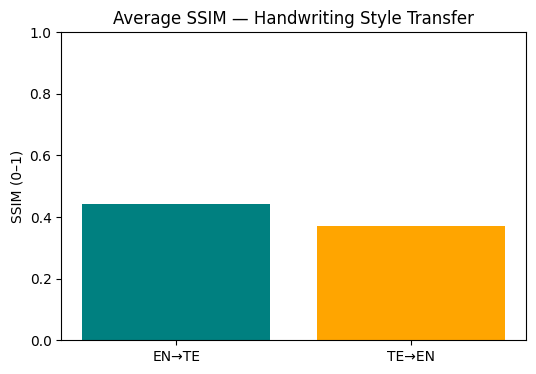

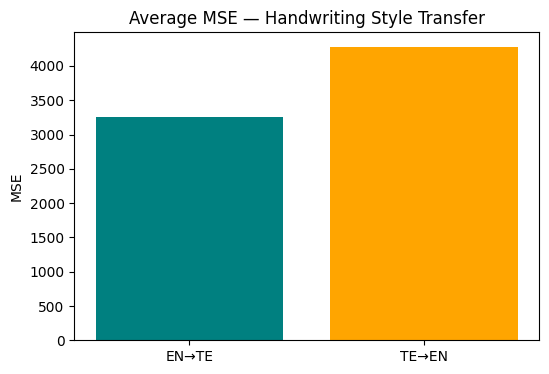

In [9]:
import matplotlib.pyplot as plt

labels = ['EN→TE', 'TE→EN']
ssim_vals = [0.443, 0.371]
mse_vals = [3258.55, 4276.51]

plt.figure(figsize=(6,4))
plt.bar(labels, ssim_vals, color=['teal','orange'])
plt.title('Average SSIM — Handwriting Style Transfer')
plt.ylabel('SSIM (0–1)')
plt.ylim(0,1)
plt.show()

plt.figure(figsize=(6,4))
plt.bar(labels, mse_vals, color=['teal','orange'])
plt.title('Average MSE — Handwriting Style Transfer')
plt.ylabel('MSE')
plt.show()

In [29]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 103.1 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 119.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 134.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.1

In [45]:
# Diagnostic test for English → Telugu Generator activity
import torch, cv2, numpy as np

test_path = random.choice(glob.glob(os.path.join(english_dir, "**", "*.png"), recursive=True))
img = cv2.imread(test_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (128, 128))
inp = torch.tensor(img / 127.5 - 1.0).unsqueeze(0).unsqueeze(0).float().to(device)

with torch.no_grad():
    out = G_EN2TE(inp)
    print(f"G_EN2TE output stats → min: {out.min().item():.4f}, max: {out.max().item():.4f}, mean: {out.mean().item():.4f}")

out_img = ((out.squeeze().cpu().numpy() + 1) / 2 * 255).astype(np.uint8)
cv2.imwrite("debug_G_EN2TE_output.png", out_img)
print("Saved sample generator output: debug_G_EN2TE_output.png")


G_EN2TE output stats → min: -0.2071, max: 0.8485, mean: 0.7298
Saved sample generator output: debug_G_EN2TE_output.png


In [10]:
# ===========================================================
#  Final Stable Gradio Interface (Automatic Brightness Correction)
# ===========================================================

import gradio as gr
import torch, cv2, os, numpy as np, random, glob
from skimage.metrics import structural_similarity as ssim, mean_squared_error as mse

# --- Paths ---
base_dir = "/blue/eee6778/mulakav"
gen_en_path = os.path.join(base_dir, "checkpoints/G_TE2EN_finetune84.pth")
gen_te_path = os.path.join(base_dir, "checkpoints/G_EN2TE_finetune84.pth")
english_dir = os.path.join(base_dir, "datasets/iam_words")
telugu_dir  = os.path.join(base_dir, "datasets/TeluguSeg")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G_EN2TE = Generator().to(device)
G_TE2EN = Generator().to(device)
G_EN2TE.load_state_dict(torch.load(gen_te_path, map_location=device))
G_TE2EN.load_state_dict(torch.load(gen_en_path, map_location=device))
G_EN2TE.eval(); G_TE2EN.eval()

# ===========================================================
# Preprocessing
# ===========================================================
def preprocess(img, direction):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    gray = cv2.fastNlMeansDenoising(gray, h=10)
    gray = cv2.GaussianBlur(gray, (3,3), 0)
    gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)
    resized = cv2.resize(gray, (128, 128))
    tensor = torch.tensor(resized / 127.5 - 1.0).unsqueeze(0).unsqueeze(0).float().to(device)
    return tensor

# ===========================================================
# Postprocessing (Automatic Polarity Detection)
# ===========================================================
def postprocess(tensor, direction):
    fake = tensor.squeeze().cpu().numpy()
    fake = np.clip(fake, -1, 1)
    fake = ((fake + 1) / 2 * 255).astype(np.uint8)
    fake = cv2.normalize(fake, None, 0, 255, cv2.NORM_MINMAX)

    # --- Auto brightness polarity detection ---
    mean_brightness = fake.mean()
    if direction == "English → Telugu":
        if mean_brightness < 128:
            print(f"[Auto Correction] Inverting (mean={mean_brightness:.1f})")
            fake = 255 - fake  # invert only when model outputs bright-on-dark
        fake = cv2.fastNlMeansDenoising(fake, h=8)
        fake = cv2.bilateralFilter(fake, 5, 50, 50)
        fake = cv2.convertScaleAbs(fake, alpha=1.4, beta=-20)
        fake = cv2.normalize(fake, None, 20, 230, cv2.NORM_MINMAX)
        fake = cv2.medianBlur(fake, 3)
    else:
        fake = cv2.fastNlMeansDenoising(fake, h=10)
        fake = cv2.medianBlur(fake, 3)
        fake = cv2.convertScaleAbs(fake, alpha=1.1, beta=10)

    return cv2.cvtColor(fake, cv2.COLOR_GRAY2RGB)

# ===========================================================
# Dataset Utilities
# ===========================================================
def sample_image(folder):
    exts = (".jpg", ".jpeg", ".png")
    imgs = glob.glob(os.path.join(folder, "**", "*.*"), recursive=True)
    imgs = [img for img in imgs if img.lower().endswith(exts)]
    if not imgs: return None
    img = cv2.imread(random.choice(imgs))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def load_sample(direction):
    folder = english_dir if direction == "English → Telugu" else telugu_dir
    img = sample_image(folder)
    if img is None: raise gr.Error(f"No valid images found in {folder}")
    return img

# ===========================================================
# Inference
# ===========================================================
def translate_style(image, direction):
    if image is None:
        return None, "Please upload or load a sample image first.", 0, 0
    inp = preprocess(image, direction)
    with torch.no_grad():
        out = G_EN2TE(inp) if direction == "English → Telugu" else G_TE2EN(inp)
        if direction == "English → Telugu":
            out = torch.clamp(out, -0.9, 0.9)
            mean_val = out.abs().mean().item()
            if mean_val < 0.08:
                out = out * 5.0
                print(f"[Auto-Gain] weak output (mean={mean_val:.3f}) → boosted ×5")

    out_img = postprocess(out, direction)
    orig_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    orig_resized = cv2.resize(orig_gray, (128, 128))
    out_gray = cv2.cvtColor(out_img, cv2.COLOR_RGB2GRAY)
    ssim_val = ssim(orig_resized, out_gray)
    mse_val = mse(orig_resized, out_gray)
    return out_img, f"SSIM: {ssim_val:.3f} | MSE: {mse_val:.2f}", ssim_val, mse_val

def reset_image(): return None

# ===========================================================
# Gradio Interface
# ===========================================================
with gr.Blocks(title="CycleGAN Handwriting Style Transfer") as demo:
    gr.Markdown("## ✍️ Handwriting Style Transfer (English ↔ Telugu)")
    gr.Markdown("Upload or load a handwriting image to visualize **style translation** using the trained CycleGAN model. The output preserves the word shape but changes handwriting style.")

    with gr.Row():
        direction = gr.Radio(["English → Telugu", "Telugu → English"], label="Choose translation direction", value="English → Telugu")
        sample_btn = gr.Button("Load Sample from Dataset")

    with gr.Row():
        input_img = gr.Image(label="Input Handwriting (Upload or Sample)", type="numpy")
        output_img = gr.Image(label="Generated Style Image")

    with gr.Row():
        metrics = gr.Textbox(label="Similarity Metrics")
        ssim_out = gr.Number(label="SSIM", interactive=False)
        mse_out = gr.Number(label="MSE", interactive=False)

    run_btn = gr.Button("Generate Style")
    sample_btn.click(fn=load_sample, inputs=direction, outputs=input_img)
    run_btn.click(fn=translate_style, inputs=[input_img, direction], outputs=[output_img, metrics, ssim_out, mse_out])
    direction.change(fn=reset_image, inputs=None, outputs=input_img)

    gr.Markdown("---")

demo.launch(server_port=8021, share=True)


* Running on local URL:  http://127.0.0.1:8021
* Running on public URL: https://5a5e46f55a33013c58.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
